# Case NPS Preditivo - Análise Exploratória


Com o crescimento acelerado do e-commerce nacional, temos o cenário de
uma empresa que passou a lidar com um volume cada vez maior de pedidos, entregas
e interações com clientes. Esse crescimento trouxe ganhos importantes de escala,
mas também revelou desafios relevantes na experiência do cliente, especialmente
refletidos na alta variabilidade do Net Promoter Score (NPS) entre diferentes perfis de
consumidores. A área de Experiência do Cliente percebeu que, mesmo com
indicadores operacionais aparentemente semelhantes, alguns clientes se tornam
promotores da marca, enquanto outros se tornam detratores.

Essa diferença levanta uma questão central para o negócio: **quais fatores
operacionais realmente influenciam a satisfação do cliente e como a empresa
pode agir de forma proativa para melhorar a experiência antes mesmo da
aplicação da pesquisa de NPS?**

Atualmente, o NPS é coletado apenas após o encerramento da jornada de
compra, o que limita a capacidade da empresa de antecipar problemas, priorizar
ações corretivas e atuar de forma preventiva. Nesse contexto, surge a necessidade de transformar dados operacionais, como informações de pedidos, logística e atendimento, em insights acionáveis, capazes de orientar decisões estratégicas e operacionais.

## Pacotes

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

## Leitura e checagem dos dados

In [41]:
dados = pd.read_csv("https://raw.githubusercontent.com/braga0m/TechChallenge1/refs/heads/main/dados/dados_ecommerce.csv")

In [22]:
dados.head(5)

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,...,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,nps_categoria,complaints,complaints_labeled,delay_categoria,repeat_purchase_30d_labeled
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,...,4,6.9,0,3,6.5,Detratores,1,Sim,2,Não
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,...,10,2.4,0,3,0.0,Detratores,1,Sim,4+,Não
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,...,5,4.8,0,7,1.5,Detratores,1,Sim,1,Não
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,...,11,5.9,0,4,0.3,Detratores,1,Sim,2,Não
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,...,0,6.1,0,3,7.9,Detratores,1,Sim,1,Não


In [23]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  2500 non-null   int64  
 1   customer_age                 2500 non-null   int64  
 2   customer_region              2500 non-null   object 
 3   customer_tenure_months       2500 non-null   int64  
 4   order_id                     2500 non-null   int64  
 5   order_value                  2500 non-null   float64
 6   items_quantity               2500 non-null   int64  
 7   discount_value               2500 non-null   float64
 8   payment_installments         2500 non-null   int64  
 9   delivery_time_days           2500 non-null   int64  
 10  delivery_delay_days          2500 non-null   int64  
 11  freight_value                2500 non-null   float64
 12  delivery_attempts            2500 non-null   int64  
 13  customer_service_c

In [24]:
dados.drop(columns=['complaints', 'repeat_purchase_30d', 'customer_id', 'order_id']).describe().round(2)

,customer_age,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,complaints_count,csat_internal_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,43.40,61.32,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,4.15,2.94
std,14.89,34.48,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,1.78,2.38
min,18.00,1.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00
25%,31.00,31.00,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,3.00,0.70
50%,43.00,62.00,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,4.00,2.80
75%,56.00,91.00,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,5.00,4.80
max,69.00,119.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,11.00,10.00


## Análise Exploratória

O Net Promoter Score (NPS) é uma métrica de lealdade e satisfação do cliente.


NPS = (Promotores – Detratores) / Número total de respondentes.  

https://fia.com.br/blog/net-promoter-score-nps/  

https://www.mercadopago.com.br/blog/nps

Em uma escala de 0 a 10, o quanto você indicaria nosso serviço para um amigo?

*   **Promotores:** atribuem nota 9 ou 10, revelando altas chances de recomendar sua empresa.  

*   **Neutros:** dão nota 7 ou 8. Sua relação com a companhia é regular, mas existem pontos a melhorar.  

*   **Detratores:** nota de 0 a 6. Estão descontentes com seu produto, serviço ou atendimento, o que pode levá-los a fazer uma propaganda negativa.






Somente 4.4% (110) dos 2500 clientes avaliados são considerados promotores.

In [30]:
#### agrupando e agregando dados de acordo com o categoria nps
x = dados.groupby("nps_categoria").size().reset_index(name="n")

x["prop"] = 100*round(x["n"] / 2500, 3)

x = x.rename(columns={"nps_classe":"Tipo", "prop":"%"})

x

,nps_categoria,n,%
0,Detratores,2109,84.4
1,Neutros,281,11.2
2,Promotores,110,4.4


Cálculo do NPS de uma empresa.

**(Promotores – Detratores)/(Número total de respondentes)**  


De acordo com o blog do Mercado Pago:

Excelente – NPS entre 75 e 100  
Muito bom – NPS entre 50 e 74  
Razoável – NPS entre 0 e 49  
Ruim – NPS entre -100 e -1

De acordo com essa métrica, o *Net Promoter Score* da empresa é considerado ruim.

In [34]:
nps_empresa = (x["n"][2] - x["n"][0])/2500

nps_empresa

np.float64(-0.7996)

Distribuição do NPS score.
Nota-se uma assimetria e concentração mais a esquerda - indicativo de que os clientes estão mais insatisfeitos, no geral.

Observe que 84.36% deram uma nota inferior a sete no quesito de satisfação.  

Distribuição assimétrica.


In [35]:
#### Tabela de frequência relativa para nps_score por faixa

# Definindo os limites das faixas (bins)
bins = list(range(10)) + [dados['nps_score'].max() + 0.001] # Bins for 0 to 9, and the last bin for 9 to max

# Definindo os rótulos para as faixas (9 labels for 9 intervals, and 1 for 9+)
labels = [f'{i} - {i+1}' for i in range(9)] + ['9+']

# Criando a nova coluna com as categorias de nps_score
dados['nps_score_faixa'] = pd.cut(dados['nps_score'], bins=bins, labels=labels, right=False)

# Calculando a frequência absoluta, relativa e acumulada relativa
freq_table = dados['nps_score_faixa'].value_counts(dropna=False).sort_index().reset_index()
freq_table.columns = ['NPS Score Faixa', 'Frequência Absoluta']
freq_table['Frequência Relativa (%)'] = (freq_table['Frequência Absoluta'] / len(dados)) * 100
freq_table['Frequência Relativa (%)'] = freq_table['Frequência Relativa (%)'].round(3)
freq_table['Frequência Relativa Acumulada (%)'] = freq_table['Frequência Relativa (%)'].cumsum().round(3)

display(freq_table)

,NPS Score Faixa,Frequência Absoluta,Frequência Relativa (%),Frequência Relativa Acumulada (%)
0,0 - 1,272,10.88,10.88
1,1 - 2,191,7.64,18.52
2,2 - 3,286,11.44,29.96
3,3 - 4,339,13.56,43.52
4,4 - 5,378,15.12,58.64
5,5 - 6,351,14.04,72.68
6,6 - 7,292,11.68,84.36
7,7 - 8,173,6.92,91.28
8,8 - 9,108,4.32,95.60
9,9+,110,4.40,100.00


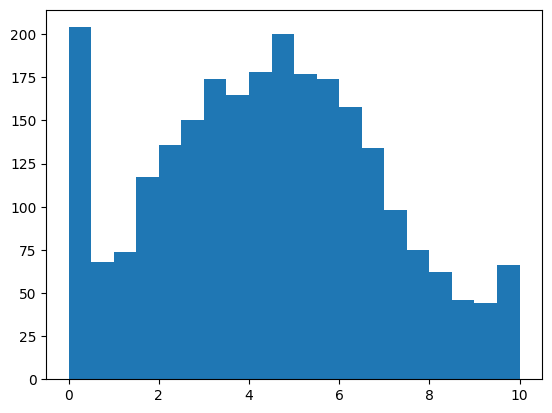

In [39]:
#### comportamento do nps - histograma
plt.hist(dados["nps_score"], bins=20)
plt.show()

<Axes: xlabel='nps_categoria', ylabel='nps_score'>

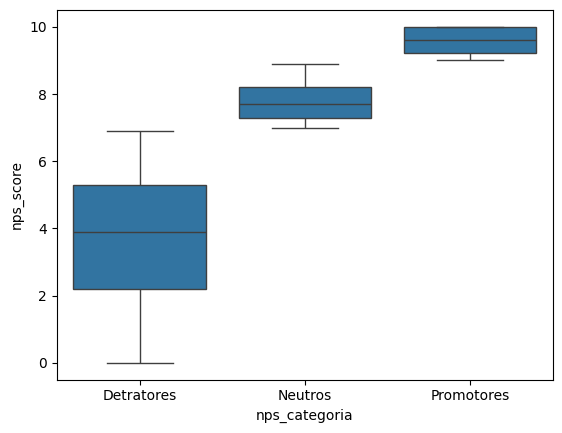

In [54]:
sns.boxplot(data=dados,  x = "nps_categoria", y="nps_score")

### Dias de atraso


Observa-se que quanto maior o atraso, menor é a satisfação do cliente. Avaliado sob o escore nps.

In [43]:
###definindo os levels da variável
dados["delay_categoria"] = pd.Categorical(
    dados["delay_categoria"],
    categories=["0", "1", "2", "3", "4+"],
    ordered=True
)

Comportamento da variável dias de atraso na entrega.

<Axes: xlabel='delay_categoria', ylabel='nps_score'>

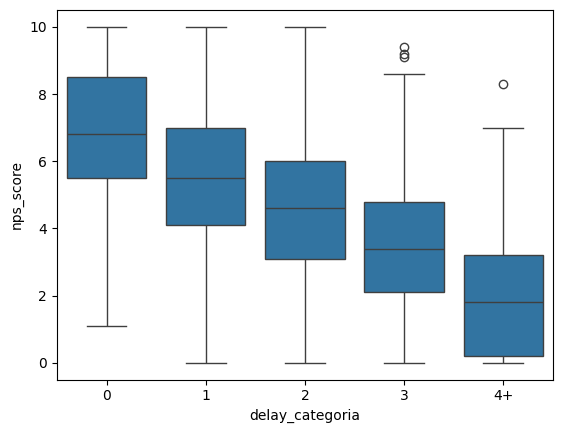

In [44]:
##
sns.boxplot(data=dados,  x = "delay_categoria", y="nps_score")

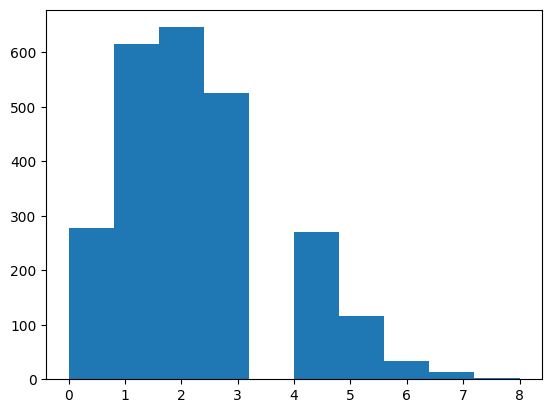

In [ ]:
#### comportamento do nps - histograma
plt.hist(dados["delivery_delay_days"])
plt.show()

In [ ]:
#### Tabela de frequência para delivery_delay_days

# Calculando a frequência absoluta
freq_table_delay = dados['delivery_delay_days'].value_counts(dropna=False).sort_index().reset_index()
freq_table_delay.columns = ['Delivery Delay Days', 'Frequência Absoluta']

# Calculando a frequência relativa
freq_table_delay['Frequência Relativa (%)'] = (freq_table_delay['Frequência Absoluta'] / len(dados)) * 100
freq_table_delay['Frequência Relativa (%)'] = freq_table_delay['Frequência Relativa (%)'].round(3)

# Calculando a frequência relativa acumulada
freq_table_delay['Frequência Relativa Acumulada (%)'] = freq_table_delay['Frequência Relativa (%)'].cumsum().round(3)

display(freq_table_delay)

,Delivery Delay Days,Frequência Absoluta,Frequência Relativa (%),Frequência Relativa Acumulada (%)
0,0,277,11.08,11.08
1,1,615,24.60,35.68
2,2,646,25.84,61.52
3,3,525,21.00,82.52
4,4,270,10.80,93.32
5,5,116,4.64,97.96
6,6,34,1.36,99.32
7,7,14,0.56,99.88
8,8,3,0.12,100.00


### Número de reclamações

<Axes: xlabel='complaints', ylabel='nps_score'>

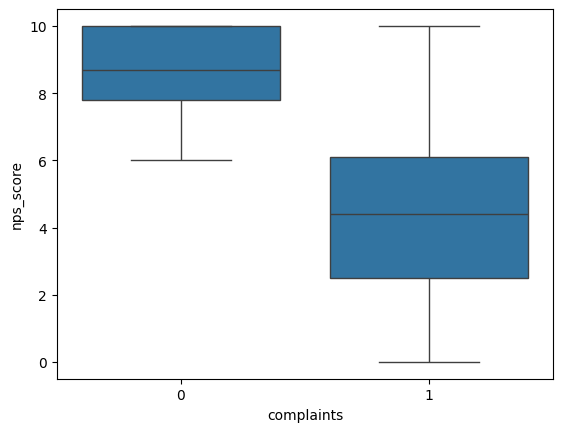

In [ ]:
##
sns.boxplot(data=dados,  x = "complaints", y="nps_score")

In [ ]:
#### Tabela de frequência para delivery_delay_days

# Calculando a frequência absoluta
freq_table_complaints_count = dados['complaints_count'].value_counts(dropna=False).sort_index().reset_index()
freq_table_complaints_count.columns = ['Número de reclamações', 'Frequência Absoluta']

# Calculando a frequência relativa
freq_table_complaints_count['Frequência Relativa (%)'] = (freq_table_complaints_count['Frequência Absoluta'] / len(dados)) * 100
freq_table_complaints_count['Frequência Relativa (%)'] = freq_table_complaints_count['Frequência Relativa (%)'].round(3)

# Calculando a frequência relativa acumulada
freq_table_complaints_count['Frequência Relativa Acumulada (%)'] = freq_table_complaints_count['Frequência Relativa (%)'].cumsum().round(3)

display(freq_table_complaints_count)

,Número de reclamações,Frequência Absoluta,Frequência Relativa (%),Frequência Relativa Acumulada (%)
0,0,23,0.92,0.92
1,1,122,4.88,5.80
2,2,277,11.08,16.88
3,3,507,20.28,37.16
4,4,600,24.00,61.16
5,5,444,17.76,78.92
6,6,266,10.64,89.56
7,7,169,6.76,96.32
8,8,63,2.52,98.84
9,9,16,0.64,99.48


### Matriz de correlação

<Axes: >

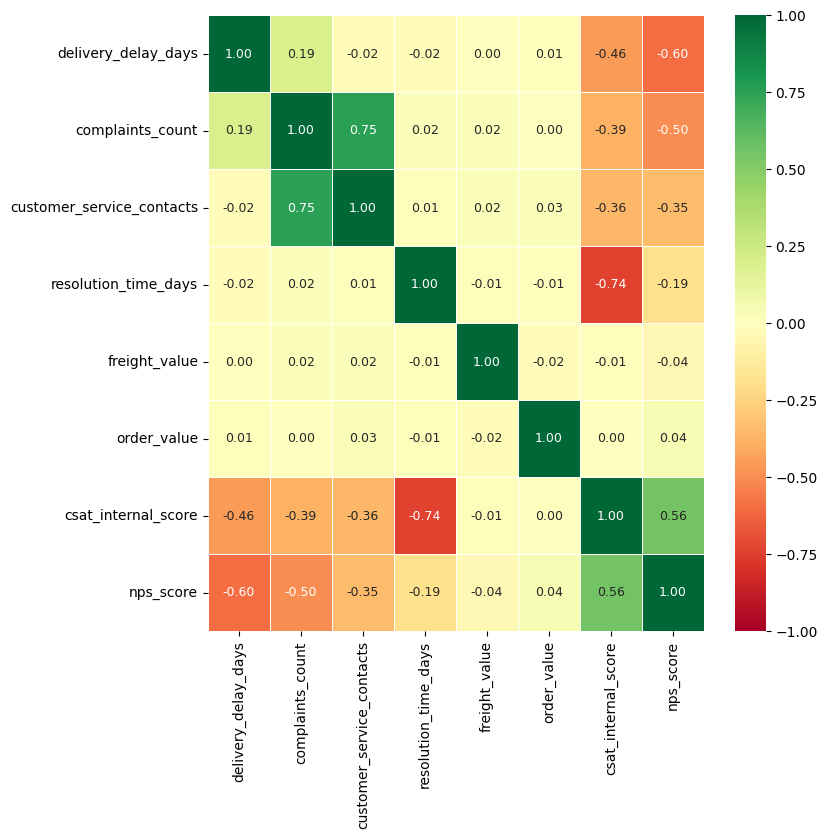

In [45]:
##### variáveis numéricas
cols_operacionais = [
    'delivery_delay_days',
    'complaints_count',
    'customer_service_contacts',
    'resolution_time_days',
    'freight_value',
    'order_value',
    'csat_internal_score',
    #'repeat_purchase_30d',
    'nps_score']

#### matriz de correlação
corr_matrix = dados[cols_operacionais].corr().round(2)

#### heatmap com a matriz de correlação
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(
    corr_matrix,
    annot=True,          # exibe os valores dentro das células
    fmt='.2f',           # duas casas decimais
    cmap='RdYlGn',       # vermelho (negativo) → amarelo → verde (positivo)
    center=0,            # centro da paleta em zero
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 9})

### Contexto

A área de Experiência do Cliente precisa quantificar o que separa um detrator de um promotor nos dados operacionais. Atraso de entrega, volume de reclamações e contatos com atendimento são as principais candidatas. Essa análise é o ponto de partida para entender onde a jornada quebra.

In [47]:
# ── Médias por categoria NPS ──────────────────────────────────
print("Médias por grupo NPS:")
dados.groupby('nps_categoria')[[
    'delivery_delay_days',
    'complaints_count',
    'customer_service_contacts',
    'resolution_time_days',
    'delivery_time_days',
    'order_value'
]].mean().round(2)

Médias por grupo NPS:


,delivery_delay_days,complaints_count,customer_service_contacts,resolution_time_days,delivery_time_days,order_value
nps_categoria,,,,,,
Detratores,2.41,4.44,1.63,5.69,7.99,429.31
Neutros,1.05,2.69,1.01,4.62,8.26,458.17
Promotores,0.72,2.27,0.67,3.70,7.94,468.08


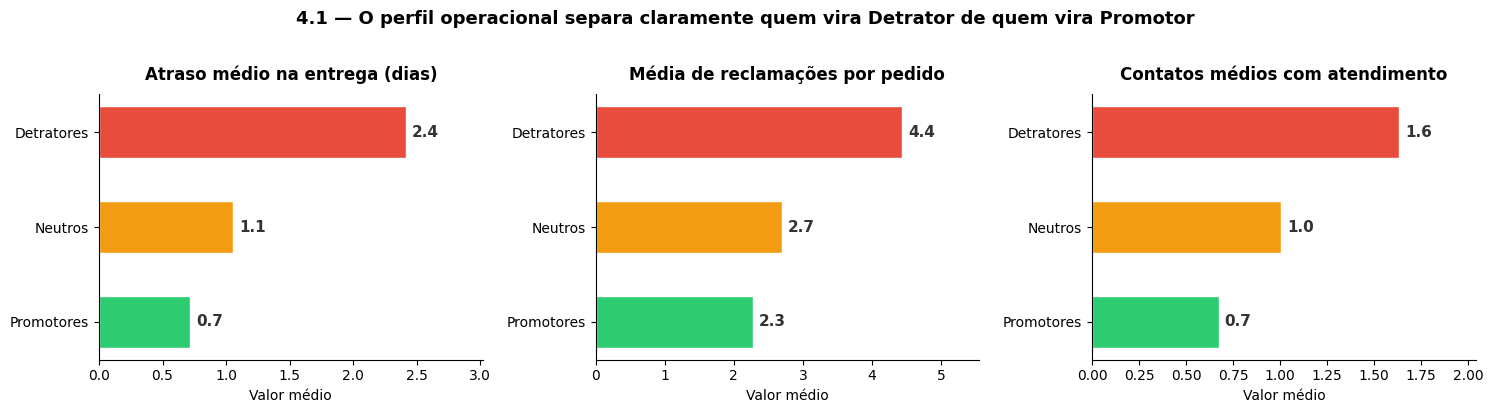

In [53]:
# ── Comparação operacional: Detratores vs. Neutros vs. Promotores ──────────────
# Pergunta: "Quem sofre mais atraso e gera mais reclamações?" → Barras de comparação
ordem   = ['Promotores', 'Neutros', 'Detratores']
palette = {'Promotores': '#2ecc71', 'Neutros': '#f39c12', 'Detratores': '#e74c3c'}

cols = {
    'delivery_delay_days':       'Atraso médio na entrega (dias)',
    'complaints_count':          'Média de reclamações por pedido',
    'customer_service_contacts': 'Contatos médios com atendimento',
}

means = dados.groupby('nps_categoria')[list(cols.keys())].mean().reindex(ordem)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (col, titulo) in zip(axes, cols.items()):
    bars = ax.barh(
        ordem, means[col],
        color=[palette[g] for g in ordem],
        height=0.55, edgecolor='white', linewidth=1
    )
    for bar, val in zip(bars, means[col]):
        ax.text(val + means[col].max() * 0.02, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}', va='center', fontsize=11, fontweight='bold', color='#333333')
    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Valor médio')
    ax.set_xlim(0, means[col].max() * 1.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('4.1 — O perfil operacional separa claramente quem vira Detrator de quem vira Promotor',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
#plt.savefig('reports/perfil_operacional.png', dpi=150, bbox_inches='tight')
plt.show()

> **📊 O que este gráfico sugere para o negócio:**
> Detratores esperam em média **muito mais dias** pela entrega, acionam o atendimento com muito mais frequência e registram muito mais reclamações do que Promotores. A diferença não é marginal — é estrutural. Isso significa que o problema não está no produto em si, mas na **experiência operacional pós-compra**: logística e atendimento são os gargalos. Cada barra vermelha acima das barras verdes é uma oportunidade de intervenção.

### Rascunhos e Testes

Sem nenhum cruzamento de variável o escore nps aparenta ser homogêneo.

<Axes: ylabel='nps_score'>

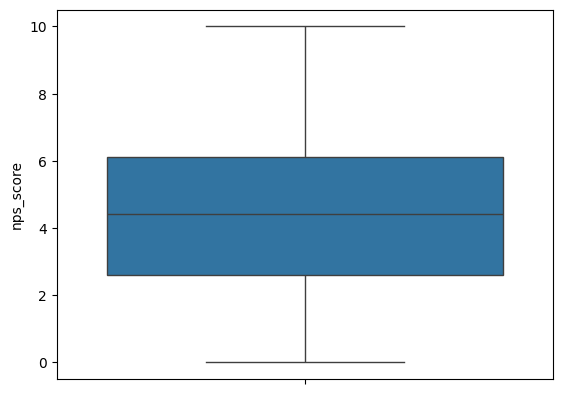

In [ ]:
####
sns.boxplot(data=dados, y="nps_score")

Como esperado, os clientes que recompraram depois de 30 dias, apresentam escore nps significativo maior.

<Axes: xlabel='repeat_purchase_30d', ylabel='nps_score'>

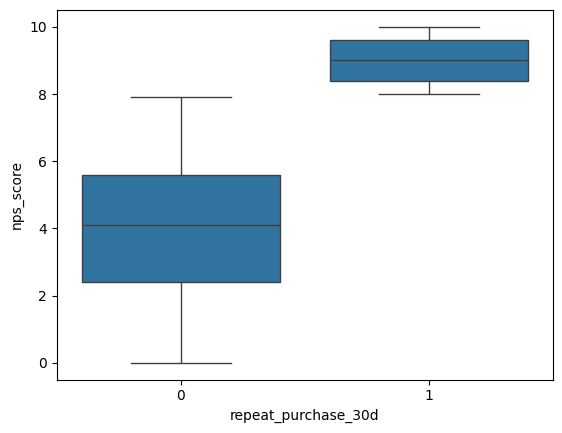

In [ ]:
####reafirma a teoria de que um nps (satisfação) alto está relacionado a recompra
sns.boxplot(data=dados, x="repeat_purchase_30d", y="nps_score")

A partir da análise gráfica, a região não aparenta afetar a satisfação do cliente de forma significativa.

<Axes: xlabel='customer_region', ylabel='nps_score'>

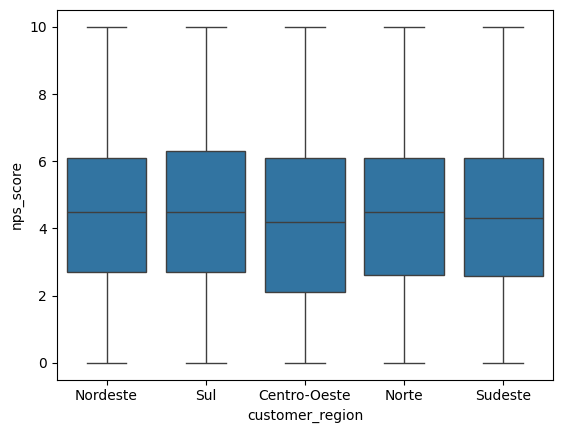

In [ ]:
#### região não aparenta ser um fator que impacta a satisfação do cliente
sns.boxplot(data=dados, x="customer_region", y="nps_score")